## simple linear regression

In [1]:
import pandas as pd
df = pd.read_csv("test.csv")
df.head(10)   #y dependent and x indenpendent

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864
5,15,9.805235
6,62,58.874659
7,95,97.617937
8,20,18.395127
9,5,8.746748


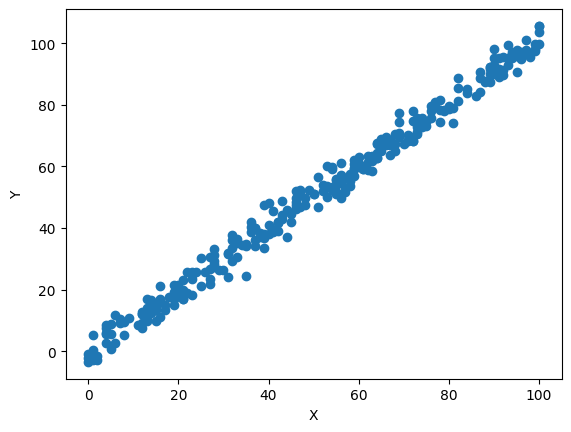

In [2]:
import matplotlib.pyplot as plt
plt.scatter(df['x'],df['y'])
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [3]:
# import lienar regression and 
from sklearn.linear_model import LinearRegression
clf = LinearRegression()

In [4]:
# let x=A y=B
A = df[['x']]
B = df[['y']]

In [5]:
#fit() is used to train the model
reg = LinearRegression()
reg.fit(A,B)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
# check for new value if its working properly
reg.predict([[50]])


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[50.25495698]])

In [7]:
# using formula y=mx+c
# calculate slope (reg.coeff=m)
reg.coef_

array([[1.01433536]])

In [8]:
# calculate intercept (reg.intercept=c)
reg.intercept_

array([-0.46181077])

In [9]:
50*1.01433536-0.46181077

50.25495723

## multiple linear regression

In [10]:
import pandas as pd
df = pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [11]:
df.shape

(10000, 6)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [13]:
df.describe()


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [14]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [15]:
X = df[['Hours Studied','Previous Scores','Sleep Hours']]
y = df['Performance Index']
X

,Hours Studied,Previous Scores,Sleep Hours
0,7,99,9
1,4,82,4
2,8,51,7
3,5,52,5
4,7,75,8
...,...,...,...
9995,1,49,4
9996,7,64,8
9997,6,83,8
9998,9,97,7


In [16]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [17]:
# Step 4: Encode the categorical column 'Extracurricular Activities'
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

In [18]:
# #now we need to make testing and training data....traning data is 70-80% and testing data is 20-30%
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.linear_model import LinearRegression
clf =  LinearRegression()
clf

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
clf.fit(X_train,y_train)
clf.predict(X_test)

array([55.50949038, 21.64844847, 47.5220034 , ..., 16.96434689,
       63.56757388, 46.35307678], shape=(2000,))

In [21]:
#check the score i.e to chk how well the model is trying to predict the score
# the more diff between predicted and actual value the score will be less and vise a versa
clf.score(X_test, y_test)

0.9877353198949831

In [22]:
#m1 m2 m3
clf.coef_

array([2.85591758, 1.01737929, 0.47339139])

In [23]:
#c
clf.intercept_

np.float64(-32.75639950098326)

In [24]:
clf.predict([[8,89,8]])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([84.42482888])

In [25]:
# then to check the actual value
# y=mx+c
#y=m1*x1+m2*x2+m3*x3+C

In [26]:
actual = 2.85591758*8+1.01737929*89+0.47339139*8

In [27]:
actual= 117.18122857-32.75639950098326

In [28]:
#actual value
actual

84.42482906901674

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # for 3D plots
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
y_pred = clf.predict(X_test)

In [31]:
y_pred

array([55.50949038, 21.64844847, 47.5220034 , ..., 16.96434689,
       63.56757388, 46.35307678], shape=(2000,))

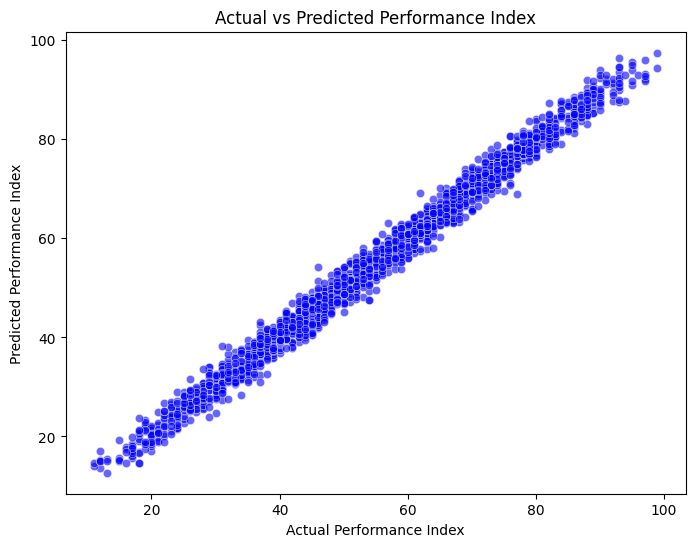

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")
plt.show()

In [33]:
## Residual Plot (to check model fit)
residuals = y_test - y_pred

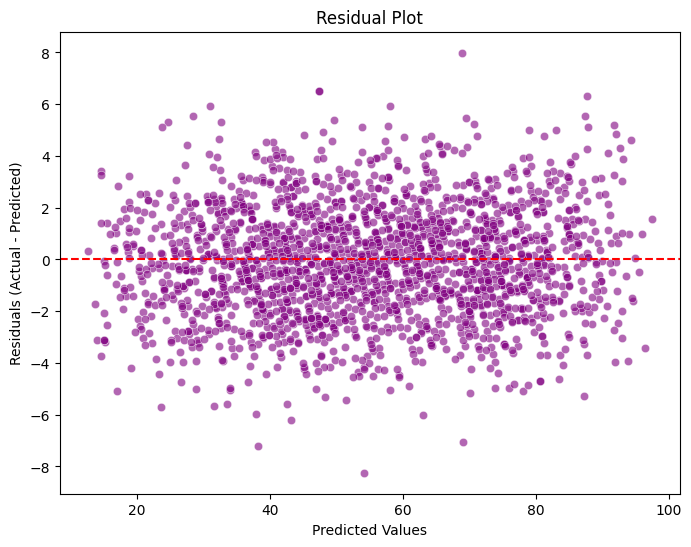

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

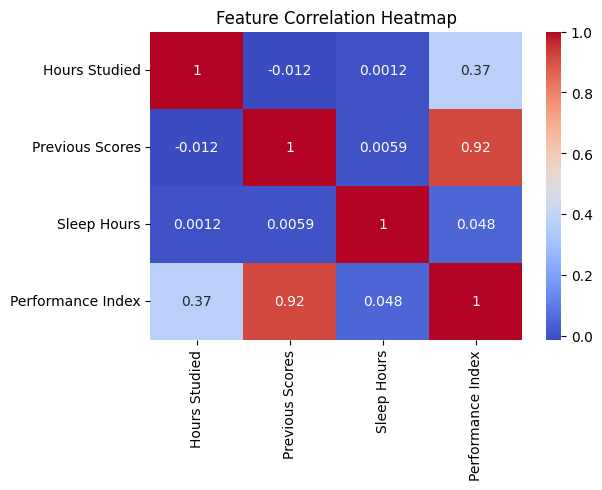

In [35]:
# Feature Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['Hours Studied','Previous Scores','Sleep Hours','Performance Index']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()